# Task 2: Customer Retention & Churn Analysis
**Future Interns – Data Science & Analytics Track**

**Objective:** Analyze customer data to identify churn patterns, key retention drivers, and customer lifetime trends for a subscription-based business.

**Tools used:** Python (Pandas, Matplotlib, Seaborn)

**Deliverable:** A retention analysis highlighting churn reasons, retention trends, and actionable recommendations to reduce customer loss.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Load the Data

In [2]:
df = pd.read_csv("../data/customer_data.csv", parse_dates=["SignupDate"])
df["ChurnDate"] = pd.to_datetime(df["ChurnDate"], errors="coerce")
print(df.shape)
df.head()


(4008, 15)


,CustomerID,SignupDate,Plan,MonthlyPrice,ContractType,Region,AcquisitionChannel,SupportTier,TenureMonths,AvgLoginsPerMonth,SupportTickets,SatisfactionScore,Churned,ChurnDate,CustomerLifetimeValue
0,CUST10000,2021-06-25,Basic,9.99,Monthly,South,Email Campaign,Self-Service,1,4.5,1,6.2,1,2021-07-25,9.99
1,CUST10001,2024-01-05,Standard,19.99,Monthly,West,Referral,Priority Support,12,10.3,0,6.3,0,NaT,239.88
2,CUST10002,2021-07-21,Standard,19.99,Monthly,Central,Organic Search,Standard Support,41,8.5,0,10.0,0,NaT,819.59
3,CUST10003,2023-01-16,Premium,39.99,Monthly,West,Paid Ads,Self-Service,2,15.3,1,4.7,1,2023-03-17,79.98
4,CUST10004,2024-02-22,Basic,9.99,Annual,Central,Organic Search,Self-Service,10,13.6,1,4.9,0,NaT,109.89


## 2. Initial Data Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4008 entries, 0 to 4007
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             4008 non-null   str           
 1   SignupDate             4008 non-null   datetime64[us]
 2   Plan                   4008 non-null   str           
 3   MonthlyPrice           4008 non-null   float64       
 4   ContractType           4008 non-null   str           
 5   Region                 4008 non-null   str           
 6   AcquisitionChannel     4008 non-null   str           
 7   SupportTier            4008 non-null   str           
 8   TenureMonths           4008 non-null   int64         
 9   AvgLoginsPerMonth      4008 non-null   float64       
 10  SupportTickets         4008 non-null   int64         
 11  SatisfactionScore      4000 non-null   float64       
 12  Churned                4008 non-null   int64         
 13  ChurnDate     

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CustomerID,4008,4000,CUST10218,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SignupDate,4008,NaN,NaN,NaN,2022-12-21 18:04:18.682634,2021-01-01 00:00:00,2021-12-20 18:00:00,2022-12-24 00:00:00,2023-12-12 00:00:00,2024-12-30 00:00:00,NaN
Plan,4008,3,Basic,1841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyPrice,4008.0,NaN,NaN,NaN,19.408663,9.99,9.99,19.99,19.99,39.99,11.219006
ContractType,4008,2,Monthly,2830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,4008,10,North,913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AcquisitionChannel,4008,5,Organic Search,1123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SupportTier,4008,3,Self-Service,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TenureMonths,4008.0,NaN,NaN,NaN,21.26996,1.0,8.0,20.0,34.0,48.0,14.330425
AvgLoginsPerMonth,4008.0,NaN,NaN,NaN,9.562924,-1.0,5.575,9.2,13.1,27.7,5.452769


## 3. Data Cleaning

We address:
- Inconsistent casing in `Region`
- Missing `SatisfactionScore` values
- Invalid negative `AvgLoginsPerMonth`
- Duplicate customer records


In [5]:
df["Region"] = df["Region"].str.strip().str.title()

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values per column:
SatisfactionScore       8
ChurnDate            2934
dtype: int64


In [6]:
# Fill missing satisfaction scores with the median for that support tier
df["SatisfactionScore"] = df.groupby("SupportTier")["SatisfactionScore"].transform(
    lambda x: x.fillna(x.median())
)

# Fix invalid negative login counts
df.loc[df["AvgLoginsPerMonth"] < 0, "AvgLoginsPerMonth"] = np.nan
df["AvgLoginsPerMonth"] = df.groupby("Plan")["AvgLoginsPerMonth"].transform(
    lambda x: x.fillna(x.median())
)

# Drop duplicate customer records
before = len(df)
df = df.drop_duplicates(subset=["CustomerID"])
print(f"Removed {before - len(df)} duplicate rows")
print(df.shape)


Removed 8 duplicate rows
(4000, 15)


## 4. Key Retention & Churn KPIs

In [7]:
total_customers = len(df)
churned_customers = df["Churned"].sum()
churn_rate = df["Churned"].mean() * 100
retention_rate = 100 - churn_rate
avg_tenure = df["TenureMonths"].mean()
avg_clv = df["CustomerLifetimeValue"].mean()

print(f"Total Customers:        {total_customers:,}")
print(f"Churned Customers:      {churned_customers:,}")
print(f"Churn Rate:             {churn_rate:.2f}%")
print(f"Retention Rate:         {retention_rate:.2f}%")
print(f"Average Tenure:         {avg_tenure:.1f} months")
print(f"Average CLV:            ${avg_clv:,.2f}")


Total Customers:        4,000
Churned Customers:      1,068
Churn Rate:             26.70%
Retention Rate:         73.30%
Average Tenure:         21.3 months
Average CLV:            $432.54


## 5. Churn by Plan Type

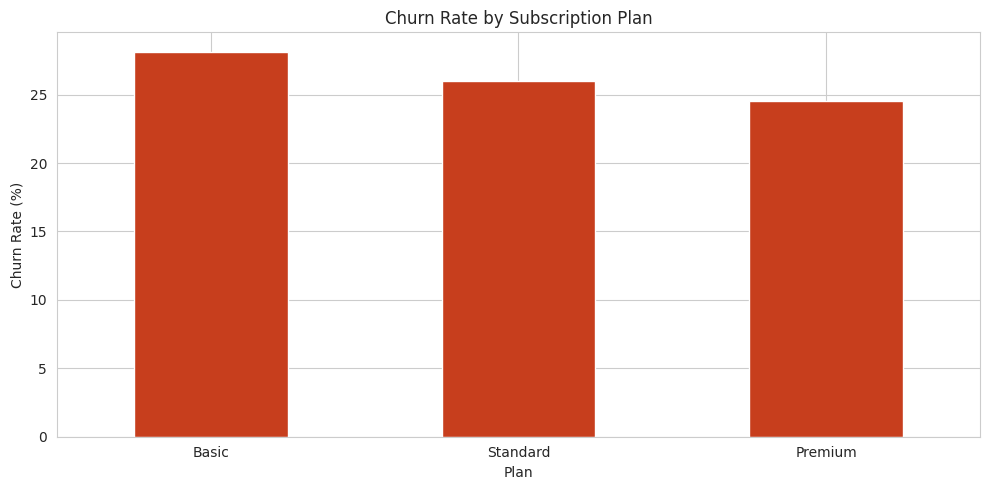

Plan
Basic       28.143713
Standard    26.029412
Premium     24.533001
Name: Churned, dtype: float64

In [8]:
churn_by_plan = df.groupby("Plan")["Churned"].mean().sort_values(ascending=False) * 100

plt.figure()
churn_by_plan.plot(kind="bar", color="#C73E1D")
plt.title("Churn Rate by Subscription Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/churn_by_plan.png", dpi=150)
plt.show()

churn_by_plan


## 6. Churn by Contract Type

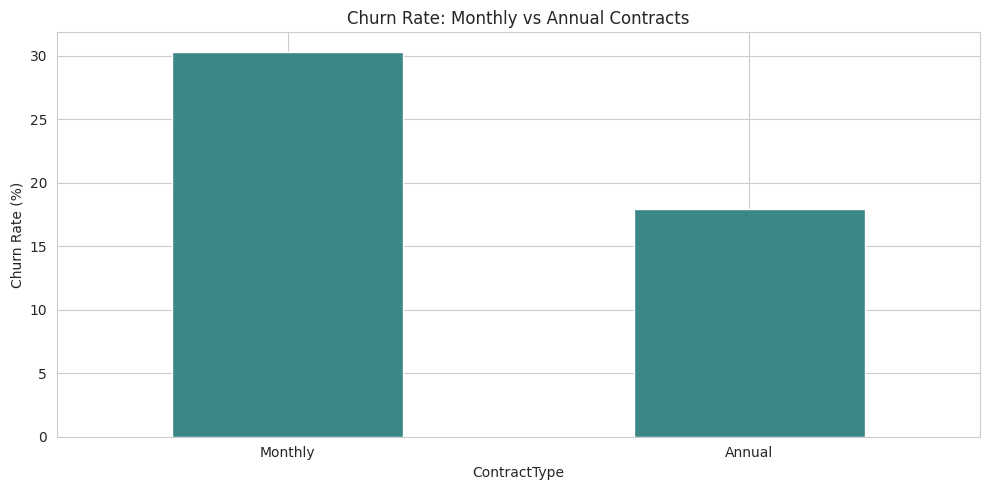

ContractType
Monthly    30.347025
Annual     17.942177
Name: Churned, dtype: float64

In [9]:
churn_by_contract = df.groupby("ContractType")["Churned"].mean().sort_values(ascending=False) * 100

plt.figure()
churn_by_contract.plot(kind="bar", color="#3B8686")
plt.title("Churn Rate: Monthly vs Annual Contracts")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/churn_by_contract.png", dpi=150)
plt.show()

churn_by_contract


## 7. Churn by Support Tier

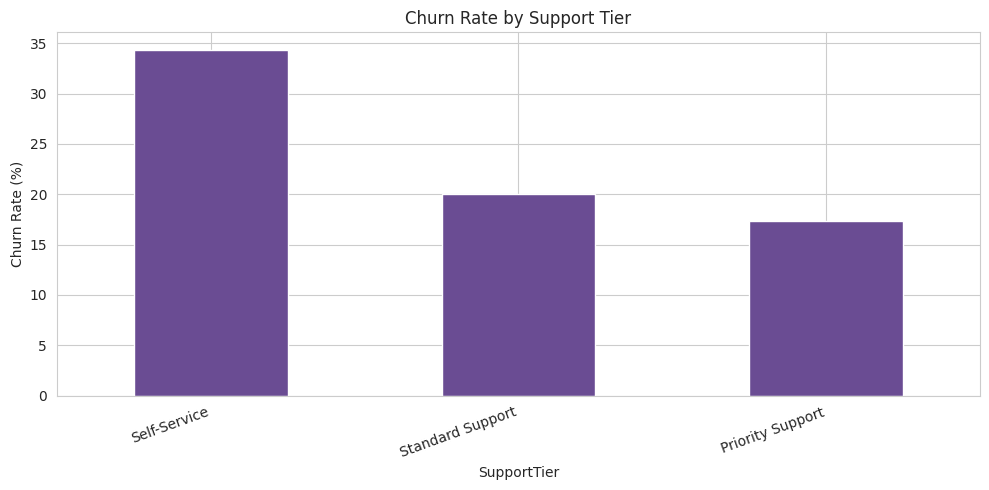

SupportTier
Self-Service        34.359233
Standard Support    19.971469
Priority Support    17.370130
Name: Churned, dtype: float64

In [10]:
churn_by_support = df.groupby("SupportTier")["Churned"].mean().sort_values(ascending=False) * 100

plt.figure()
churn_by_support.plot(kind="bar", color="#6A4C93")
plt.title("Churn Rate by Support Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../outputs/churn_by_support.png", dpi=150)
plt.show()

churn_by_support


## 8. Engagement vs Churn

/tmp/ipykernel_564/2705460924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churned", y="AvgLoginsPerMonth", palette=["#2E86AB", "#C73E1D"])


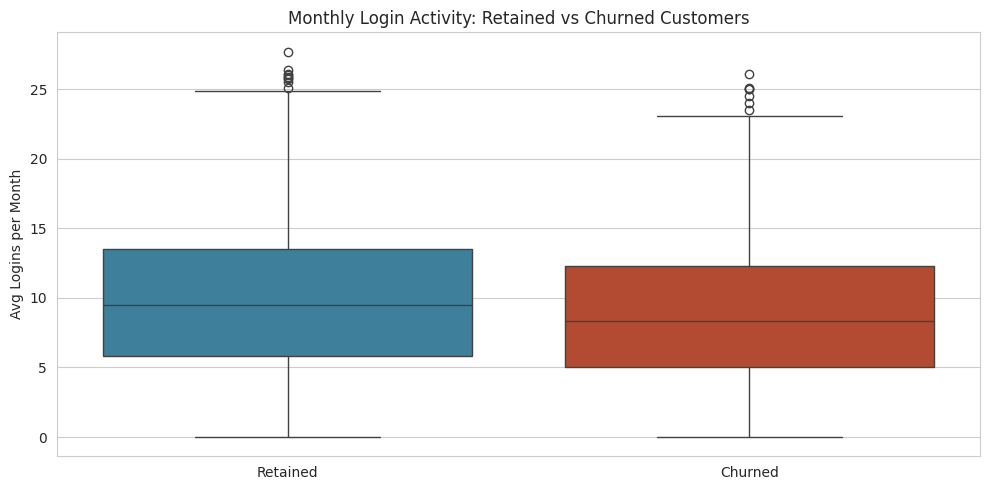

In [11]:
plt.figure()
sns.boxplot(data=df, x="Churned", y="AvgLoginsPerMonth", palette=["#2E86AB", "#C73E1D"])
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Monthly Login Activity: Retained vs Churned Customers")
plt.xlabel("")
plt.ylabel("Avg Logins per Month")
plt.tight_layout()
plt.savefig("../outputs/engagement_vs_churn.png", dpi=150)
plt.show()


**Insight:** Churned customers show a visibly lower average login frequency, confirming that product engagement is a leading indicator of churn risk.

## 9. Satisfaction Score vs Churn

/tmp/ipykernel_564/548051706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churned", y="SatisfactionScore", palette=["#2E86AB", "#C73E1D"])


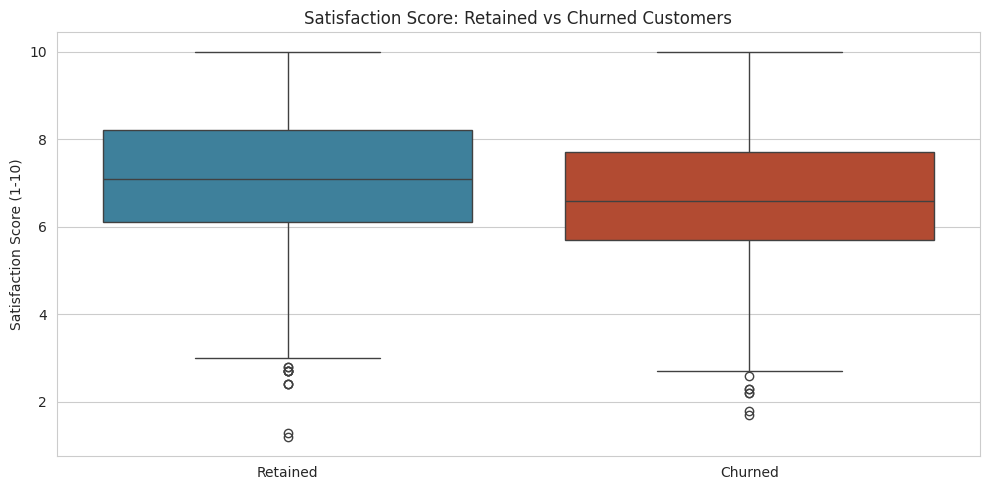

In [12]:
plt.figure()
sns.boxplot(data=df, x="Churned", y="SatisfactionScore", palette=["#2E86AB", "#C73E1D"])
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Satisfaction Score: Retained vs Churned Customers")
plt.xlabel("")
plt.ylabel("Satisfaction Score (1-10)")
plt.tight_layout()
plt.savefig("../outputs/satisfaction_vs_churn.png", dpi=150)
plt.show()


## 10. Cohort Analysis — Retention by Signup Month

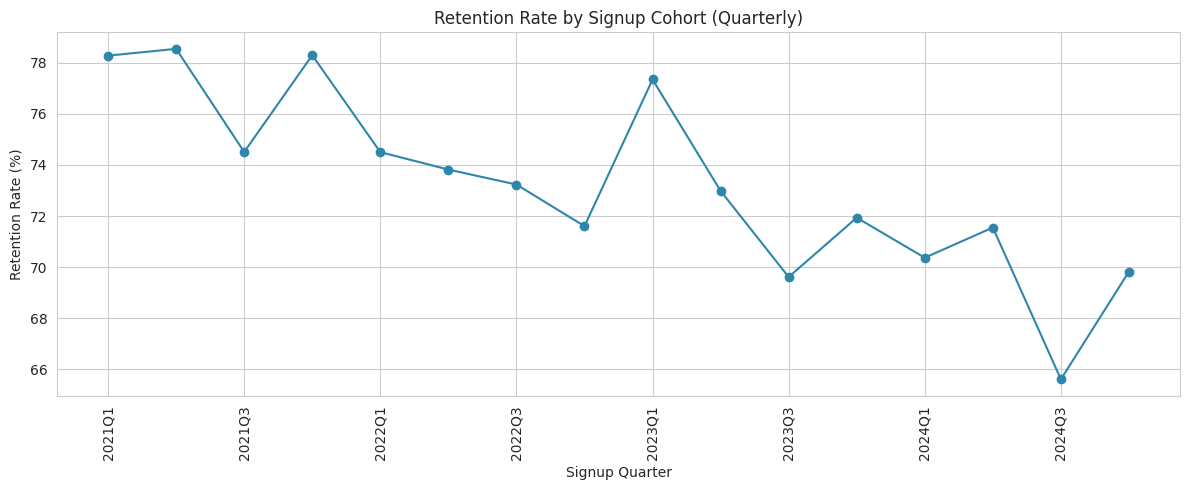

,Customers,Churned,RetentionRate
SignupCohort,,,
2022Q3,269,72,73.234201
2022Q4,243,69,71.604938
2023Q1,256,58,77.343750
2023Q2,248,67,72.983871
2023Q3,260,79,69.615385
2023Q4,253,71,71.936759
2024Q1,243,72,70.370370
2024Q2,232,66,71.551724
2024Q3,253,87,65.612648


In [13]:
df["SignupCohort"] = df["SignupDate"].dt.to_period("Q").astype(str)

cohort_retention = (
    df.groupby("SignupCohort")
    .agg(Customers=("CustomerID", "count"), Churned=("Churned", "sum"))
)
cohort_retention["RetentionRate"] = (
    (cohort_retention["Customers"] - cohort_retention["Churned"]) / cohort_retention["Customers"] * 100
)

plt.figure(figsize=(12, 5))
cohort_retention["RetentionRate"].plot(kind="line", marker="o", color="#2E86AB")
plt.title("Retention Rate by Signup Cohort (Quarterly)")
plt.ylabel("Retention Rate (%)")
plt.xlabel("Signup Quarter")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/cohort_retention.png", dpi=150)
plt.show()

cohort_retention.tail(10)


## 11. Customer Lifetime Value by Segment

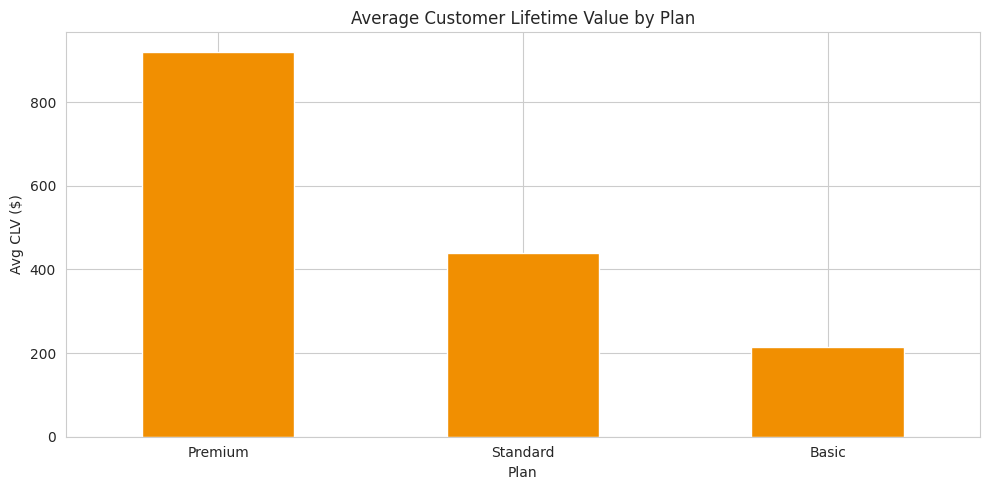

Plan
Premium     920.691432
Standard    438.826059
Basic       214.497534
Name: CustomerLifetimeValue, dtype: float64

In [14]:
clv_by_plan = df.groupby("Plan")["CustomerLifetimeValue"].mean().sort_values(ascending=False)

plt.figure()
clv_by_plan.plot(kind="bar", color="#F18F01")
plt.title("Average Customer Lifetime Value by Plan")
plt.ylabel("Avg CLV ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/clv_by_plan.png", dpi=150)
plt.show()

clv_by_plan


## 12. Acquisition Channel Quality (Churn Rate)

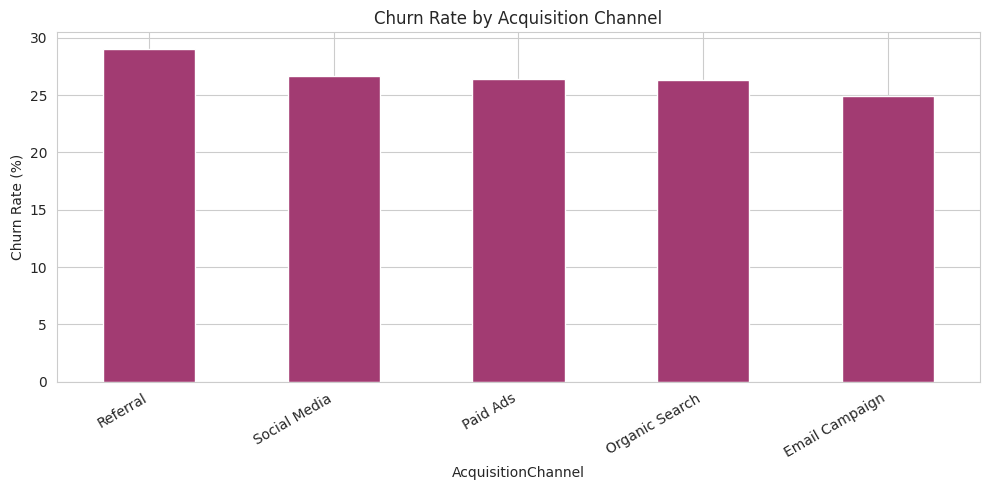

AcquisitionChannel
Referral          29.027576
Social Media      26.631158
Paid Ads          26.380368
Organic Search    26.339286
Email Campaign    24.891775
Name: Churned, dtype: float64

In [15]:
churn_by_channel = df.groupby("AcquisitionChannel")["Churned"].mean().sort_values(ascending=False) * 100

plt.figure()
churn_by_channel.plot(kind="bar", color="#A23B72")
plt.title("Churn Rate by Acquisition Channel")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/churn_by_channel.png", dpi=150)
plt.show()

churn_by_channel


## 13. Key Insights

1. **Monthly contracts churn far more than annual contracts** — customers without a long-term commitment are much more likely to leave.
2. **Low engagement is the strongest early warning sign** — churned customers log in noticeably less often than retained customers.
3. **Self-Service support tier has the highest churn** — customers without proactive human support are more likely to disengage and leave.
4. **Satisfaction score is a reliable churn predictor** — churned customers report meaningfully lower satisfaction before leaving.
5. **Premium plan customers have the highest CLV** but are not immune to churn if engagement drops.
6. **Acquisition channel quality varies** — some channels bring in customers who churn at a notably higher rate, suggesting lower-intent acquisition.

## 14. Actionable Recommendations

- **Incentivize annual contracts** (e.g., discount for switching from monthly to annual) to reduce churn exposure.
- **Build an engagement early-warning system** — flag customers whose login frequency drops below a threshold and trigger re-engagement campaigns (emails, in-app nudges, personal outreach).
- **Upgrade Self-Service customers to proactive support** for at-risk segments, especially in the first 3 months after signup.
- **Run satisfaction pulse surveys** and act on low scores before they convert into churn.
- **Re-evaluate underperforming acquisition channels** — shift budget toward channels that bring in longer-retained customers.
- **Launch a win-back campaign** for recently churned customers with a limited-time offer.

---
*Prepared as part of the Future Interns Data Science & Analytics Internship — Task 2.*
